# CUSTOMER CHURN PREDICTION ANALYSIS

## Business Analytics Internship Project

### Project Overview

Customer churn is a major business challenge because losing existing customers can negatively affect revenue and long-term business growth. This project analyzes customer data to identify patterns and factors associated with customer churn and develops a machine-learning model to predict customers who are likely to leave.

The analysis will combine exploratory data analysis with machine learning to generate insights that can support customer retention strategies and business decision-making.

### Project Objectives

* Analyze customer churn patterns and distribution.
* Identify factors associated with customer churn.
* Explore customer characteristics and behaviors related to churn.
* Build a machine-learning model to predict customer churn.
* Evaluate the performance of the prediction model.
* Provide actionable recommendations to improve customer retention.

### Tools and Technologies

* **Python**
* **Jupyter Notebook**
* **Pandas** — data manipulation and cleaning
* **Matplotlib** — data visualization
* **Scikit-learn** — machine learning and model evaluation


# 1. IMPORT LIBRARIES

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# 2. LOAD THE CHURN DATASET 

In [59]:
file_path=r"C:\Users\Zainab\Documents/Churn prediction/Dataset/churn-bigml-80.csv"
df=pd.read_csv(file_path)


# 3. DATA INSPECTION & CLEANING 

## 3.1 Data Inspection

In [60]:
df.head(10)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
5,AL,118,510,Yes,No,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,False
6,MA,121,510,No,Yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,False
7,MO,147,415,Yes,No,0,157.0,79,26.69,103.1,94,8.76,211.8,96,9.53,7.1,6,1.92,0,False
8,WV,141,415,Yes,Yes,37,258.6,84,43.96,222.0,111,18.87,326.4,97,14.69,11.2,5,3.02,0,False
9,RI,74,415,No,No,0,187.7,127,31.91,163.4,148,13.89,196.0,94,8.82,9.1,5,2.46,0,False


In [61]:
df.shape

(2666, 20)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [63]:
df.duplicated().sum()

np.int64(0)

### Initial Data Understanding Findings

The dataset contains **2,666 customer records and 20 variables**. The dataset includes customer demographic information, service plans, usage behavior, call activity, charges, customer service interactions, and a Boolean churn indicator.

The initial data-quality assessment shows that:

* The dataset contains **2,666 rows and 20 columns**.
* There are **no missing values** across the 20 variables.
* The dataset contains **no duplicate rows**, indicating that each customer record is unique within the dataset.
* The dataset contains **3 categorical variables**: `State`, `International plan`, and `Voice mail plan`.
* Most variables are numerical, representing customer usage, calls, minutes, and charges.
* The `Churn` column is a **Boolean variable** and serves as the target variable for the churn prediction model.

Overall, the initial inspection indicates that the dataset is structurally complete and does not require missing-value treatment or duplicate removal at this stage. Further analysis will focus on understanding the distribution of customer behavior, churn patterns, and potential factors associated with customer attrition.


In [64]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


### Numerical Data Findings

The numerical summary shows that the dataset contains **2,666 observations** across all numerical variables, confirming that there are no missing values in these fields.

Some key observations include:

* **Account length** ranges from **1 to 243 days**, with an average of approximately **101 days**.
* **Total day minutes** range from **0 to 350.8 minutes**, with an average of approximately **179.5 minutes**.
* **Total evening minutes** range from **0 to 363.7 minutes**, averaging approximately **200.4 minutes**.
* **Total night minutes** range from **43.7 to 395 minutes**, with an average of approximately **201.2 minutes**.
* **Total international minutes** range from **0 to 20 minutes**, with an average of approximately **10.2 minutes**.
* **Customer service calls** range from **0 to 9 calls**, with an average of approximately **1.6 calls**.
* The `Number vmail messages` variable ranges from **0 to 50**, indicating that some customers do not use voicemail while others use it more frequently.
* The call-related variables show variation in customer usage, with some customers making substantially more calls than others.

The summary also shows some variables with minimum values of **0**, which may be valid values but will be examined further during data cleaning and exploratory analysis to determine whether they represent normal customer behavior or require attention.

Overall, the numerical variables show considerable variation in customer usage patterns, charges, and service interactions. This variation provides useful information for investigating factors that may be associated with customer churn.


## 3.2 Customer Churn Distribution

In [65]:
df["Churn"].value_counts()

Churn
False    2278
True      388
Name: count, dtype: int64

### Churn Distribution Findings

The target variable shows that **2,278 customers (85.4%) did not churn**, while **388 customers (14.6%) churned**.

This indicates that the dataset has an **imbalanced churn distribution**, with non-churned customers making up the majority of the records. This imbalance will be considered when evaluating the machine-learning model, since accuracy alone may not fully reflect how well the model identifies customers who churn.


## 3.3  Customer Service Plan Distributions

In [66]:
print(df["International plan"].value_counts())
print()
print(df["Voice mail plan"].value_counts())

International plan
No     2396
Yes     270
Name: count, dtype: int64

Voice mail plan
No     1933
Yes     733
Name: count, dtype: int64


### Service Plan Findings

The service-plan distribution shows that most customers do not subscribe to an international plan or a voice mail plan.

* **International plan:** 2,396 customers do not have an international plan, while 270 customers have one.
* **Voice mail plan:** 1,933 customers do not have a voice mail plan, while 733 customers have one.

This shows that the international plan is less common among customers, while the voice mail plan has a higher level of adoption. These service-plan variables will be examined further to determine whether they are associated with customer churn.


## 3.4 Check the Distribution of Customers by State

In [67]:
df["State"].value_counts().head(10)

State
WV    88
MN    70
NY    68
VA    67
AL    66
OH    66
WY    66
OR    62
NV    61
WI    61
Name: count, dtype: int64

### State Distribution Findings

The dataset contains customers from multiple states. Based on the top 10 states by customer count, `West Virginia (WV)` has the highest number of customers with **88 records**, followed by `Minnesota` with **70** and `New York` with **68**.

The remaining states in the top 10 range from **61** to **67** customers. This indicates that customers are distributed across different geographic locations rather than being concentrated in a single state.

State will be considered as a categorical feature during further analysis to determine whether geographic location is associated with customer churn.


# 4.  EXPLORATORY DATA ANALYSIS (EDA)

## 4.1. Churn by international plan

In [68]:
df.groupby("International plan")["Churn"].mean()*100

International plan
No     11.268781
Yes    43.703704
Name: Churn, dtype: float64

### Churn by International Plan Findings

The analysis shows a clear difference in churn rates between customers with and without an international plan.

* Customers **without an international plan** had a churn rate of **11.27%**.
* Customers **with an international plan** had a churn rate of **43.70%**.

This indicates that customers with an international plan had a substantially higher observed churn rate in this dataset. The relationship will be considered as a potential predictor of churn during the machine-learning stage.

Customers subscribed to international plans may require closer attention from the retention team, particularly when combined with other indicators of churn risk. However, this finding represents an association in the dataset and does not establish that having an international plan directly causes churn.


## 4.2. Churn by voice mail plan

In [69]:
df.groupby("Voice mail plan")["Churn"].mean() * 100

Voice mail plan
No     16.709778
Yes     8.867667
Name: Churn, dtype: float64

### Findings

The analysis shows a difference in churn rates based on whether customers have a voice mail plan.

* Customers **without a voice mail plan** had a churn rate of **16.71%**.
* Customers **with a voice mail plan** had a churn rate of **8.87%**.

Customers with a voice mail plan therefore had a lower observed churn rate in this dataset. This suggests that the voice mail plan may be associated with customer retention, although the analysis does not establish that the plan directly causes lower churn.

The variable will be included as a potential predictor during the machine-learning stage.


## 4.3 Average daytime usage by churn status

In [70]:
df.groupby("Churn")["Total day minutes"].mean()

Churn
False    175.104346
True     205.181186
Name: Total day minutes, dtype: float64

### Findings

The analysis shows that customers who churned had higher average daytime usage than customers who remained with the service.

* **Non-churned customers:** 175.10 average daytime minutes
* **Churned customers:** 205.18 average daytime minutes

Churned customers therefore used approximately **30.08 more daytime minutes on average**.

This suggests that higher daytime usage is associated with customer churn in this dataset. The variable will be considered as a potential predictor in the churn prediction model.


## 4.4 Customer Service Calls

In [71]:
df.groupby("Churn")["Customer service calls"].mean()

Churn
False    1.453029
True     2.206186
Name: Customer service calls, dtype: float64

### Findings
The analysis shows that churned customers made more customer service calls on average than customers who did not churn.

* **Non-churned customers:** 1.45 average customer service calls
* **Churned customers:** 2.21 average customer service calls

Churned customers made approximately **0.75 more customer service calls on average**.

This suggests that higher customer service contact is associated with increased churn in this dataset. This may indicate that customers experiencing service-related difficulties or requiring more support could be at greater risk of leaving. Further analysis and the machine-learning model will help determine how useful this variable is for predicting churn.


## 4.5 Compare average international calls by churn status 

In [72]:
df.groupby("Churn")["Total intl calls"].mean()

Churn
False    4.538191
True     4.051546
Name: Total intl calls, dtype: float64

### Findngs
The analysis shows a small difference in average international call activity between churned and non-churned customers.

* **Non-churned customers:** 4.54 average international calls
* **Churned customers:** 4.05 average international calls

Churned customers made approximately **0.49 fewer international calls on average** than non-churned customers.

The difference is relatively small compared with some of the other patterns observed in the analysis. This suggests that international call frequency alone may have limited usefulness for explaining churn, although its predictive value will ultimately be assessed during model development.


## 4.6 Churn rate by State 

In [73]:
state_churn=df.groupby("State")["Churn"].mean()*100
state_churn.sort_values(ascending=False).head(10)

State
TX    29.090909
NJ    28.000000
AR    23.404255
MD    23.333333
MS    22.916667
SC    22.448980
ME    22.448980
MI    22.413793
PA    22.222222
NV    21.311475
Name: Churn, dtype: float64

### Findings
Churn rates varied across states. `Texas` had the highest observed churn rate at **29.09%**, followed by `New Jersey` at **28.00%** and `Arkansas` at **23.40%** among the states shown. This suggests that customer location may be useful when analyzing churn patterns and building the prediction model. However, the differences represent associations within this dataset and do not imply that location causes churn.



## 4.7  Compare key numerical features by churn status

In [74]:
df.groupby("Churn")[[
    "Total day minutes",
    "Total eve minutes",
    "Total night minutes",
    "Total intl minutes",
    "Total intl calls",
    "Customer service calls"
]].mean()

,Total day minutes,Total eve minutes,Total night minutes,Total intl minutes,Total intl calls,Customer service calls
Churn,,,,,,
False,175.104346,198.853380,200.464091,10.13784,4.538191,1.453029
True,205.181186,209.385309,205.307216,10.81933,4.051546,2.206186


### Finding
The comparison shows differences in several usage and service-related variables between churned and non-churned customers. The clearest differences observed in the earlier analysis were `daytime minutes` and `customer service calls`.
 
These differences indicate that customer usage behaviour and service interactions may contain useful information for identifying customers associated with higher churn. These variables can therefore be included in the machine-learning model to determine whether they remain useful when considered together with other customer characteristics.

# 5. FEATURE ENGINEERING / ENCODING

Before building the machine-learning model, the dataset needs to be transformed into a format that can be processed by the algorithm. Categorical variables are converted into numerical representations, while the target variable is separated from the predictor variables.

## 5.1 Create a Copy for Machine Learning

A separate copy of the cleaned dataset is created so that the original dataset remains unchanged while the machine-learning preparation is performed.

In [75]:
model_df = df.copy()

## 5.2 Convert Categorical Columns into Numerical Values
The `International plan` and `Voice mail plan` columns contain categorical values such as "Yes" and "No". These values are converted into numerical representations so they can be used by the machine-learning model.

In [76]:
model_df["International plan"] = model_df["International plan"].map({
    "No": 0,
    "Yes": 1
})

model_df["Voice mail plan"] = model_df["Voice mail plan"].map({
    "No": 0,
    "Yes": 1
})

model_df["Churn"] = model_df["Churn"].astype(int)

## 5.3 Converting State into dummy variables 
There are many states, so instead of manually assigning numbers to them, we use one-hot encoding

In [77]:
model_df = pd.get_dummies(
    model_df,
    columns=["State"],
    drop_first=True,
    dtype=int
)

In [78]:
X = model_df.drop("Churn", axis=1)
y = model_df["Churn"]

## 5.4 Convert Churn into Numerical Values
The `Churn` variable is originally stored as a Boolean value. It is converted into numerical values where `0` represents customers who did not churn and `1` represents customers who churned.

In [79]:
model_df["Churn"] = model_df["Churn"].astype(int)

## 5.5 Check the Prepared Dataset

The transformed dataset is inspected to confirm that the encoding process was completed correctly.

In [80]:
model_df.head(10)

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,128,415,0,1,25,265.1,110,45.07,197.4,99,...,0,0,0,0,0,0,0,0,0,0
1,107,415,0,1,26,161.6,123,27.47,195.5,103,...,0,0,0,0,0,0,0,0,0,0
2,137,415,0,0,0,243.4,114,41.38,121.2,110,...,0,0,0,0,0,0,0,0,0,0
3,84,408,1,0,0,299.4,71,50.90,61.9,88,...,0,0,0,0,0,0,0,0,0,0
4,75,415,1,0,0,166.7,113,28.34,148.3,122,...,0,0,0,0,0,0,0,0,0,0
5,118,510,1,0,0,223.4,98,37.98,220.6,101,...,0,0,0,0,0,0,0,0,0,0
6,121,510,0,1,24,218.2,88,37.09,348.5,108,...,0,0,0,0,0,0,0,0,0,0
7,147,415,1,0,0,157.0,79,26.69,103.1,94,...,0,0,0,0,0,0,0,0,0,0
8,141,415,1,1,37,258.6,84,43.96,222.0,111,...,0,0,0,0,0,0,0,0,1,0
9,74,415,0,0,0,187.7,127,31.91,163.4,148,...,0,0,0,0,0,0,0,0,0,0


## 5.6 Check Dataset Dimensions

The number of rows and columns is checked after encoding to understand how the transformation affected the structure of the dataset.

In [81]:
model_df.shape

(2666, 69)

## 5.7 Check Data Types

The data types are checked to confirm that the variables are in suitable formats for machine learning.

In [82]:
model_df.dtypes

Account length           int64
Area code                int64
International plan       int64
Voice mail plan          int64
Number vmail messages    int64
                         ...  
State_VT                 int64
State_WA                 int64
State_WI                 int64
State_WV                 int64
State_WY                 int64
Length: 69, dtype: object

## 5.8 Separate Features and Target

The dataset is divided into:

- **X:** customer characteristics and service variables used to make predictions.
- **y:** the `Churn` variable that the model will predict.

In [83]:
X = model_df.drop("Churn", axis=1)
y = model_df["Churn"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (2666, 68)
Target: (2666,)


# 6. MACHINE LEARNING MODEL

A Random Forest Classification model is used to predict whether a customer is likely to churn. The dataset is divided into training and testing sets so that the model can learn from one portion of the data and be evaluated on previously unseen data.

## 6.1 Split the Data into Training and Testing Sets

The dataset is divided into **80%** training data and **20%** testing data. Stratification is used to maintain a similar proportion of churned and non-churned customers in both datasets.

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 6.2 Create the Random Forest Model

A Random Forest Classifier is selected because it can handle multiple numerical and categorical-derived features and can capture relationships between different customer characteristics.

In [85]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (2132, 68)
Testing features: (534, 68)
Training target: (2132,)
Testing target: (534,)


## 6.3 Train the Model

The Random Forest model is trained using the training dataset. During training, the model learns patterns in the customer data that can help distinguish churned customers from non-churned customers.

In [86]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

## 6.4 Train the Model

The Random Forest model is trained using the training dataset. During training, the model learns patterns in the customer data that can help distinguish churned customers from non-churned customers.

In [87]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 6.5 Make Predictions
The trained Random Forest model is used to predict the churn status of customers in the test dataset.

The predictions are stored in `y_pred` and will be compared with the actual churn outcomes in the model evaluation section.

In [88]:
y_pred = model.predict(X_test)

# 7. MODEL EVALUATION

The model is evaluated using multiple performance metrics. Accuracy provides an overall measure of correct predictions, while precision, recall, and F1-score provide more detailed information about how well the model identifies churned customers. The confusion matrix provides a direct view of correct and incorrect classifications.

## 7.1 Model Accuracy

Accuracy measures the proportion of all test customers that the model classified correctly.

In [89]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9438202247191011


### Finding

The model achieved an **accuracy of 94%**, meaning it correctly classified **94% of customers in the test set**. This indicates that the model performs well overall in distinguishing between customers who churn and those who do not.


## 7.2 Classification Report

The classification report provides precision, recall, and F1-score for both churn classes. These metrics provide more detail about the model's ability to correctly identify churned customers.

In [90]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       456
           1       1.00      0.62      0.76        78

    accuracy                           0.94       534
   macro avg       0.97      0.81      0.87       534
weighted avg       0.95      0.94      0.94       534



### Finding

For the churn class, the model recorded a **precision of 1.00, recall of 0.62, and F1-score of 0.76**. This means that when the model predicts a customer will churn, the prediction is correct. However, the recall of **0.62** shows that the model identifies only **62% of customers who actually churned**, meaning that **38% of actual churners were missed**.

This is important because failing to identify a customer who later churns represents a missed opportunity for possible retention action. Although the model achieved an overall **accuracy of 94%**, the lower recall for the churn class suggests that accuracy alone does not fully reflect how well the model detects customers at risk of leaving.


## 7.3 ROC-AUC Score

The ROC-AUC score measures how well the model distinguishes between customers who churned and customers who did not churn across different classification thresholds.

A higher ROC-AUC indicates better separation between the two classes.

In [91]:
from sklearn.metrics import roc_auc_score

y_probability = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8880876068376068


### Finding

The model achieved a **ROC-AUC score of 0.89**, indicating a strong ability to distinguish between customers who are likely to churn and those who are likely to stay. This supports using the model to **prioritize customers for retention actions**, while recognizing that some churners may still be missed.


## 7.4 Confusion Matrix

The confusion matrix shows the number of customers that were correctly and incorrectly classified into the churn and non-churn groups.

In [92]:
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[456   0]
 [ 30  48]]


## 7.5 Visualize the Confusion Matrix

A heatmap is used to make the correct and incorrect predictions easier to interpret.

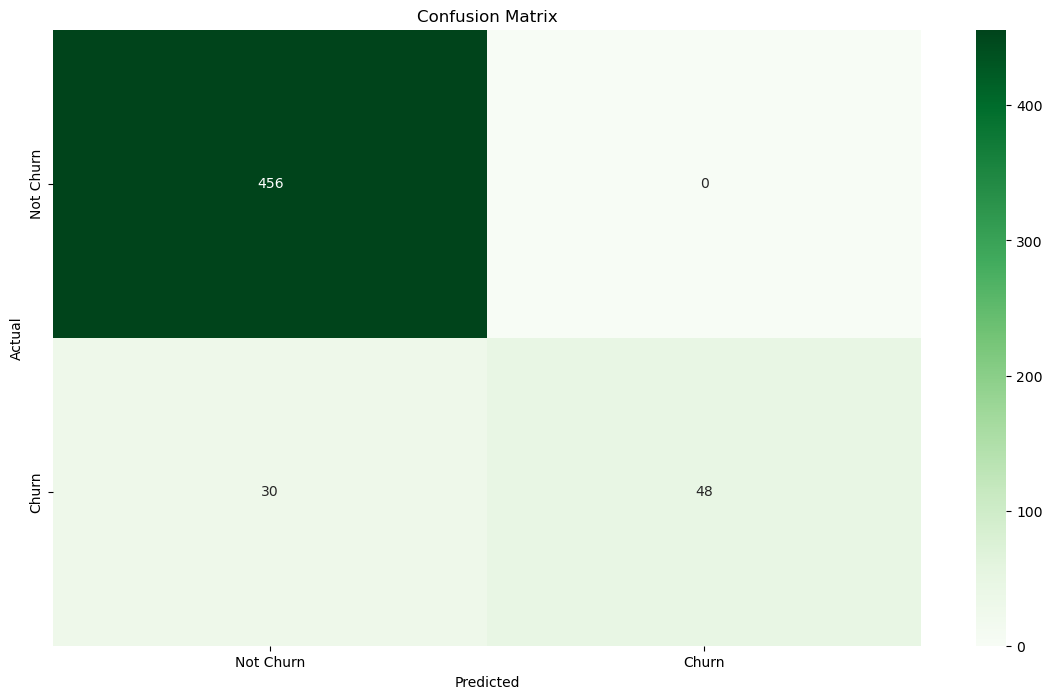

In [93]:
plt.figure(figsize=(14,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Finding

The confusion matrix shows that the model correctly identified **456 non-churning customers and 48 churning customers**, while **30 churners were missed**. With **no false-positive churn predictions**, retention efforts can be focused on customers the model identifies as at risk. However, the **30 missed churners represent potential lost retention opportunities**, which could affect customer retention and revenue.


## 7.6 Feature-Importance 
The feature-importance analysis identified the variables with the greatest contribution to the model's predictions.
 
These variables provide additional insight into the customer characteristics and behaviours that the model found useful when distinguishing churned customers from non-churned customers. They can also guide further business investigation into potential churn-risk factors.

In [94]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
5,Total day minutes,0.125266
7,Total day charge,0.116878
17,Customer service calls,0.107714
2,International plan,0.082525
10,Total eve charge,0.055317
8,Total eve minutes,0.051396
16,Total intl charge,0.042068
15,Total intl calls,0.039335
14,Total intl minutes,0.038817
12,Total night calls,0.037959


### Finding

**Total day minutes** was the most influential feature in predicting churn, followed by **total day charge** and **customer service calls**. This suggests that customers’ daytime usage and their interactions with customer service were important factors in the model’s churn predictions. The **international plan** also contributed meaningfully, while international and night-time usage had a smaller influence.


## 7.7 Visualize the top 10 important features

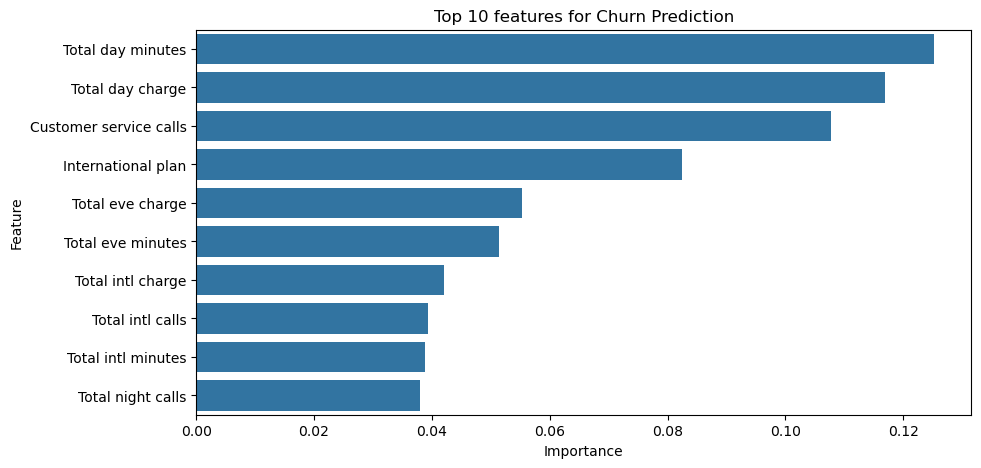

In [95]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 features for Churn Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Overall Model Finding

The model achieved **94% accuracy** and a **ROC-AUC score of 0.89**, indicating strong overall performance. Of the **78 customers who actually churned, 48 were correctly identified while 30 were missed**, giving a churn recall of **62%**. **Total day minutes, total day charge, and customer service calls** were the most influential features. Overall, the model can support **customer retention efforts by identifying customers at risk of churn**, although improving churn detection could help reduce missed retention opportunities.


# 8. KEY INSIGHTS & FINDINGS

The analysis identified several customer behaviours and characteristics associated with churn.

### 1. Customer churn is relatively concentrated
Out of **2,666** customers, **388** customers churned, representing **14.6%** of the dataset, while **2,278** customers did not churn.
 
Although most customers remained with the service, the churned group represents a meaningful portion of the customer base. Identifying these customers early could help the business reduce customer losses.

### 2. International-plan customers showed higher churn  
Customers with an international plan had a churn rate of **43.70%**, compared with **11.27%** for customers without an international plan.

The large difference suggests that international-plan customers deserve further investigation. Pricing, service experience, usage patterns, or plan suitability may be relevant factors to examine.

### 3. Voice-mail-plan customers showed lower churn
Customers without a voice-mail plan had a churn rate of **16.71%**, compared with **8.87%** among customers with a voice-mail plan.

Voice-mail-plan status may provide useful information when identifying customer segments with different churn patterns. However, the analysis does not establish that having the plan itself prevents churn.

### 4. Churned customers had higher daytime usage
Churned customers averaged approximately **205.18 daytime minutes**, compared with **175.10 minutes** among non-churned customers.

The approximately **30-minute difference** suggests that higher daytime usage may be associated with greater churn risk. This could indicate that some customers may have plans that do not adequately match their usage levels.

### 5. Churned customers made more customer service calls
Churned customers averaged approximately **2.21 customer service calls**, compared with **1.45 calls** among non-churned customers.

More frequent service interactions may indicate unresolved issues, dissatisfaction, or greater support needs. Customer service activity can therefore be useful when identifying customers who may require additional attention.

### 6. International call activity showed only a small difference
Non-churned customers averaged approximately **4.54 international calls**, while churned customers averaged approximately **4.05 calls**.
  
The difference is relatively small compared with some of the other variables examined. International call frequency alone may therefore provide limited information about churn.

### 7. Churn varied across states
Churn rates differed across states. `Texas` recorded the highest observed churn rate among the states shown at **29.09%**, followed by `New Jersey` at **28.00%**.
 
Regional differences may help identify areas that require further investigation. However, state should be treated as an indicator for further analysis rather than evidence that location itself causes churn.

### 8. Customer service interactions add an important churn signal

The Random Forest model identified **customer service calls (0.108)** as the **third most influential feature** in predicting churn, alongside usage and billing-related variables. This suggests that service interactions provide additional information for identifying customers at risk of churn beyond their usage levels. Monitoring customers with frequent service calls could therefore support earlier retention intervention.


# 9. BUSINESS RECOMMENDATIONS

Based on the findings from the analysis and machine-learning model, the following actions are recommended:

### 1. Develop a customer churn-risk monitoring process

Customers identified by the model as having characteristics associated with churn can be monitored and prioritized for retention activities.

### 2. Investigate international-plan customers

The business should review the pricing, service quality, usage behaviour, and customer experience of international-plan customers to understand why this segment has a higher observed churn rate.

### 3. Investigate customers with frequent service calls

Customer service calls were the third most influential feature in the churn model, with an importance score of 0.108. Customers making frequent service calls should be reviewed to identify recurring complaints or unresolved issues and address them before they result in churn.

### 4. Review plans for high-usage customers

Customers with high daytime usage could be assessed to determine whether their current plans match their usage patterns. The business could test whether offering more suitable plans improves customer satisfaction and retention.

### 5. Monitor regional churn patterns

States with higher observed churn rates can be investigated further to determine whether there are differences in customer behaviour, service experience, pricing, or other business factors.

### 7. Track retention outcomes

After implementing retention activities, the business should monitor churn rates over time to determine whether the interventions are associated with improved customer retention.

### 8. Use the model to prioritize retention outreach

The model correctly identified 48 of the 78 customers who actually churned, while missing 30. The business can use the model to prioritize identified at-risk customers for retention actions, while continuing to review missed churn cases to improve future predictions.

# 10. CONCLUSION

This project combined exploratory data analysis and machine learning to investigate customer churn and identify factors associated with customers leaving the service.

The analysis found that **churned customers had higher daytime usage**, averaging **205.18 minutes compared with 175.10 minutes for non-churned customers**. Customer service interactions also emerged as an important churn signal, while the analysis identified differences in customer plans, usage behaviour, and geographic churn patterns.

The Random Forest model achieved **94.38% accuracy** and a **ROC-AUC of 0.89**. It correctly identified **48 of the 78 actual churners**, while **30 churners were missed**. Feature importance showed that **total day minutes, total day charge, and customer service calls** were the most influential variables in the model's predictions.

Based on these findings, retention efforts should focus on **high-usage customers**, particularly those whose plans may not adequately match their usage needs, and customers with **frequent customer service interactions** who may require faster resolution of recurring issues. The model can also be used to **prioritize at-risk customers for targeted retention outreach**, while missed churn cases should be reviewed to improve future predictions.

Overall, the analysis provides a data-driven basis for understanding churn and supporting targeted retention strategies, while further testing and monitoring should be conducted before the model is used as the sole basis for customer decisions.


# 11. PROJECT SUMMARY

## Project Title

**Customer Churn Prediction and Analysis**

## Business Problem

Customer churn can reduce revenue and increase the cost of acquiring replacement customers. The objective of this project was to analyze customer churn patterns and develop a machine-learning model that can help identify customers who may be at risk of leaving.

## Dataset

- **Records:** 2,666 customers
- **Variables:** 20
- **Missing values:** None identified
- **Duplicate records:** None identified
- **Target variable:** Churn

## Analytical Process

1. Data loading
2. Data inspection
3. Data-quality assessment
4. Churn analysis
5. Exploratory data analysis
6. Feature engineering
7. Categorical encoding
8. Train-test splitting
9. Random Forest classification
10. Model evaluation
11. Feature-importance analysis
12. Business insights
13. Business recommendations

## Tools and Technologies

- Python
- Jupyter Notebook
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

## Final Business Objective

To use customer data and machine learning to better understand churn patterns, identify potential churn-risk customers, and support data-driven customer-retention strategies.